# Model Training and Comparison | Titanic Dataset

**Content:**

1. Load engineered features
2. Class distribution assessment
3. Cross-validation comparison (full classification report)
4. Train/test split and validation predictions
5. Confusion matrices
6. Key takeaways and model selection

## 1. Load Engineered Features

Load the engineered features produced by `03_feature_engineering.ipynb`.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import confusion_matrix, make_scorer, accuracy_score, precision_score, recall_score, f1_score

from titanic_ml.models import ModelRegistry
from titanic_ml.evaluation import compute_metrics, plot_cv_comparison

%matplotlib inline

SEED = 42
CV_FOLDS = 5
TEST_SPLIT = 0.2

# Load engineered features and target
X_all = pd.read_csv("../data/train_engineered.csv")
y_all = pd.read_csv("../data/y_train.csv").squeeze()

print(f"Features: {list(X_all.columns)}")
print(f"Full dataset: {X_all.shape[0]} rows, {X_all.shape[1]} features")

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Other', 'Title_Rev']
Full dataset: 889 rows, 15 features


## 2. Class Distribution Assessment

Check the target class balance to decide whether imbalance handling is needed.

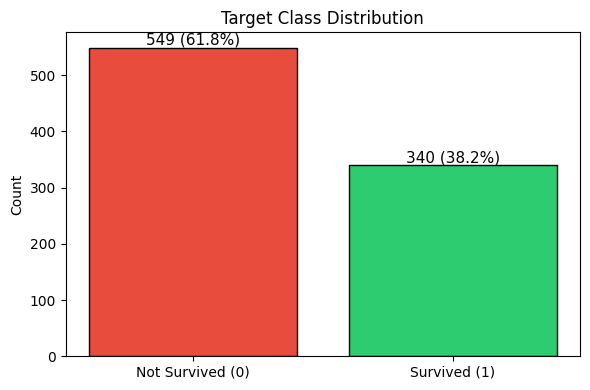

Class ratio: 61.8% / 38.2%


In [33]:
# Class distribution
class_counts = y_all.value_counts()
class_pcts = y_all.value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Not Survived (0)", "Survived (1)"], class_counts.values,
              color=["#e74c3c", "#2ecc71"], edgecolor="black")
for bar, count, pct in zip(bars, class_counts.values, class_pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{count} ({pct:.1f}%)", ha="center", fontsize=11)
ax.set_ylabel("Count")
ax.set_title("Target Class Distribution")
plt.tight_layout()
plt.show()

print(f"Class ratio: {class_pcts[0]:.1f}% / {class_pcts[1]:.1f}%")

Note:
- The dataset has a mild 62/38 split. We use `class_weight="balanced"` where supported and stratified splits throughout to preserve the class ratio in every fold.

## 3. Cross-Validation Comparison

Stratified 5-fold CV on the full dataset with full classification report (accuracy, precision, recall, F1).

,accuracy,precision,recall,f1
Model,,,,
Logistic Regression,0.8189 ± 0.0074,0.7502 ± 0.0153,0.7912 ± 0.0388,0.7693 ± 0.0147
Decision Tree,0.7874 ± 0.0273,0.7278 ± 0.0384,0.7118 ± 0.0480,0.7189 ± 0.0361
Random Forest,0.8088 ± 0.0178,0.7674 ± 0.0052,0.7176 ± 0.0667,0.7400 ± 0.0359
Gradient Boosting,0.8301 ± 0.0214,0.8211 ± 0.0291,0.7118 ± 0.0531,0.7613 ± 0.0356


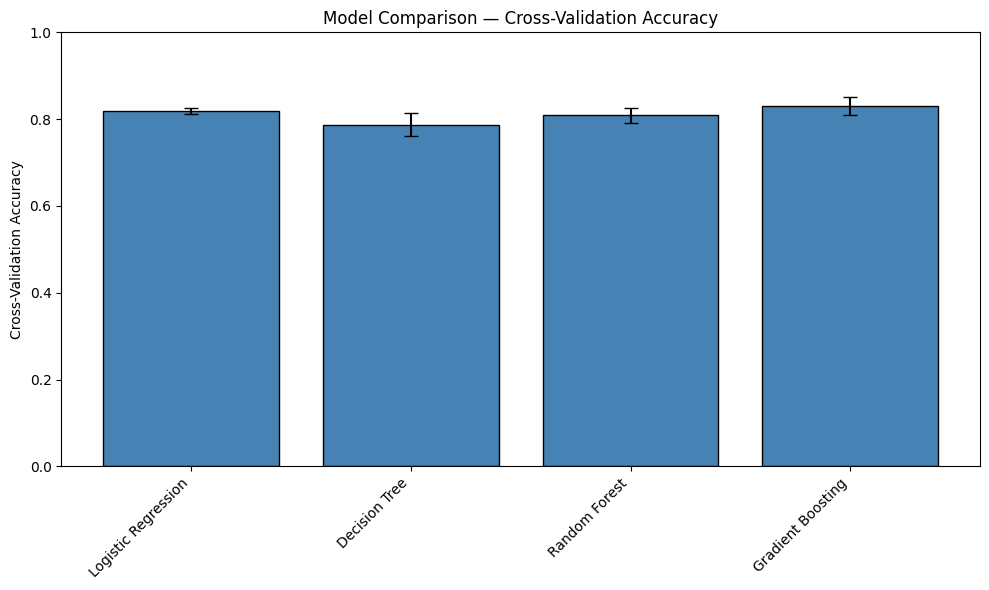

In [34]:
# Define models
model_configs = {
    "Logistic Regression": ModelRegistry(
        "logistic_regression",
        hyperparams={"max_iter": 1000, "class_weight": "balanced"},
        random_seed=SEED),
    "Decision Tree": ModelRegistry(
        "decision_tree",
        hyperparams={"class_weight": "balanced"},
        random_seed=SEED),
    "Random Forest": ModelRegistry(
        "random_forest",
        hyperparams={"n_estimators": 100, "class_weight": "balanced"},
        random_seed=SEED),
    "Gradient Boosting": ModelRegistry(
        "gradient_boosting",
        hyperparams={"n_estimators": 100, "learning_rate": 0.1},
        random_seed=SEED),
}

# Cross-validation with full classification report
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
}
cv_splitter = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

cv_results = {}
for name, model in model_configs.items():
    cv = cross_validate(model.model, X_all, y_all, cv=cv_splitter, scoring=scoring)
    cv_results[name] = {
        "accuracy":  f"{cv['test_accuracy'].mean():.4f} ± {cv['test_accuracy'].std():.4f}",
        "precision": f"{cv['test_precision'].mean():.4f} ± {cv['test_precision'].std():.4f}",
        "recall":    f"{cv['test_recall'].mean():.4f} ± {cv['test_recall'].std():.4f}",
        "f1":        f"{cv['test_f1'].mean():.4f} ± {cv['test_f1'].std():.4f}",
        "_cv_mean_accuracy": cv['test_accuracy'].mean(),
        "_cv_std_accuracy": cv['test_accuracy'].std(),
    }

# Results table
cv_display = pd.DataFrame(cv_results).T[["accuracy", "precision", "recall", "f1"]]
cv_display.index.name = "Model"
display(cv_display)

# CV accuracy chart
plot_results = {
    name: {"cv_mean_accuracy": r["_cv_mean_accuracy"], "cv_std_accuracy": r["_cv_std_accuracy"]}
    for name, r in cv_results.items()
}
display(plot_cv_comparison(plot_results))

Note:
- Gradient Boosting leads in CV accuracy (0.830 ± 0.021) and precision (0.821), but has the lowest recall (0.712), missing ~29% of actual survivors.
- Logistic Regression is a close second (0.819 ± 0.007) with the best recall (0.791) and highest F1 (0.769). Most stable performance across folds.
- Decision Tree is the weakest (0.787 ± 0.027) and has the highest variance, which indicates overfitting.
- Random Forest (0.809) sits between LR and GB but has high recall variance (± 0.067).
- All models show precision > recall, i.e., they're better at avoiding false positives than catching all survivors. The latter observation can be an effect of the imbalanced classes.

## 4. Train/Test Split and Validation Predictions

Now we make a single 80/20 stratified split, train each model on the training portion,
and generate predictions on the held-out validation set for confusion matrix analysis.

In [35]:
# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=TEST_SPLIT, random_state=SEED, stratify=y_all
)

print(f"Train: {X_train.shape[0]} rows, Validation: {X_val.shape[0]} rows")

# Train and predict
models = {}
for name, model in model_configs.items():
    model.train(X_train, y_train)
    preds = model.predict(X_val)
    models[name] = (model, preds)
    metrics = compute_metrics(y_val, preds)
    print(f"{name:25s}  acc={metrics['accuracy']:.4f}  prec={metrics['precision']:.4f}  "
          f"rec={metrics['recall']:.4f}  f1={metrics['f1']:.4f}")

print("\nAll models trained and evaluated on validation set.")

Train: 711 rows, Validation: 178 rows
Logistic Regression        acc=0.8315  prec=0.7794  rec=0.7794  f1=0.7794
Decision Tree              acc=0.7528  prec=0.6667  rec=0.7059  f1=0.6857
Random Forest              acc=0.7865  prec=0.7273  rec=0.7059  f1=0.7164
Gradient Boosting          acc=0.8371  prec=0.8095  rec=0.7500  f1=0.7786

All models trained and evaluated on validation set.


## 5. Confusion Matrices

Breakdown of predictions vs actual labels for each model.

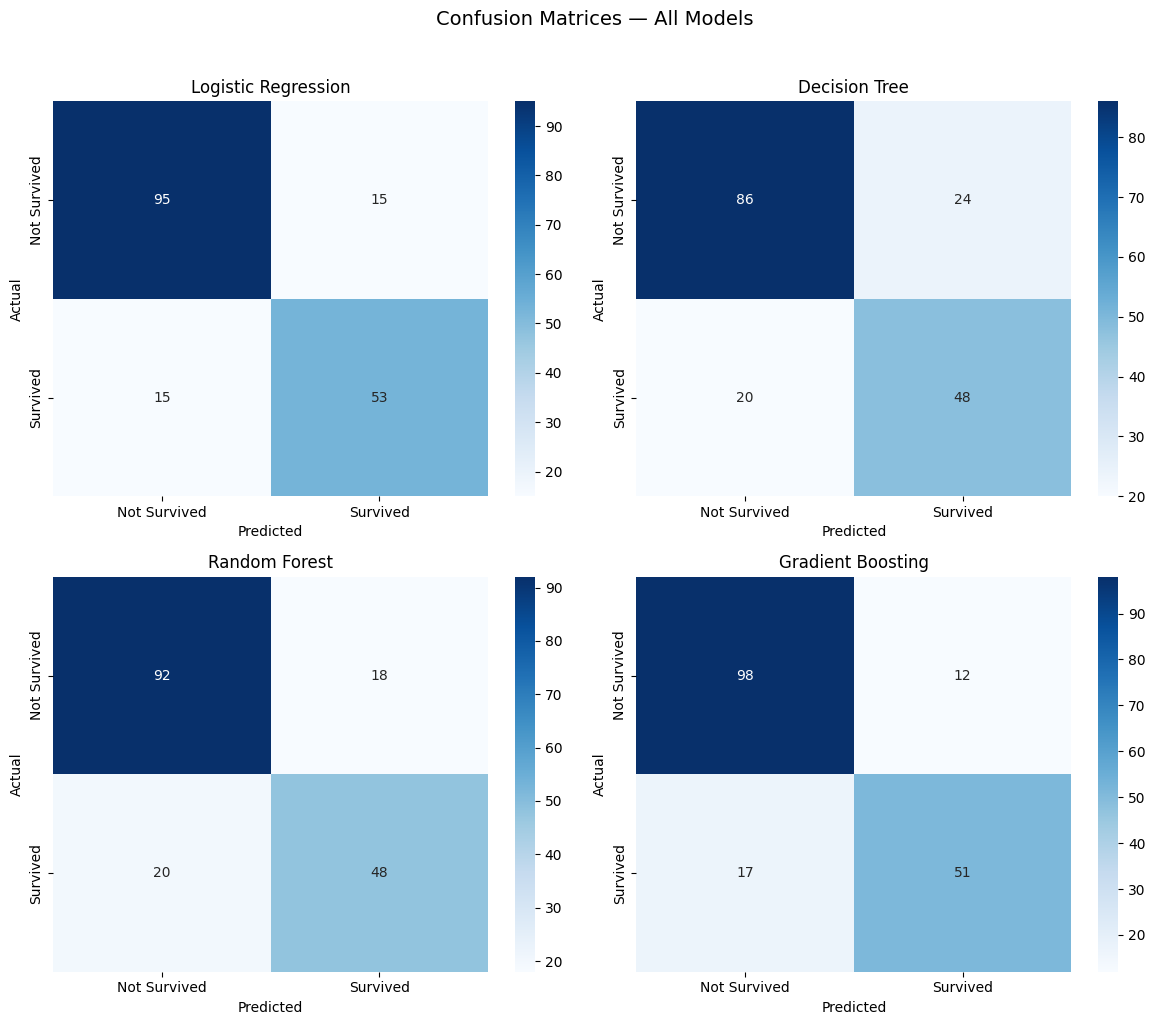

In [36]:
model_names = list(models.keys())
n_models = len(model_names)
ncols = 2
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows))
axes = axes.flatten()

for idx, name in enumerate(model_names):
    _, preds = models[name]
    cm = confusion_matrix(y_val, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Not Survived", "Survived"],
                yticklabels=["Not Survived", "Survived"],
                ax=axes[idx])
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")
    axes[idx].set_title(f"{name}")

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Confusion Matrices — All Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Note:
- GB has the fewest false positives (12) and best true negative rate (98/110), explaining its higher precision.
- LR has the fewest false negatives (15), consistent with its best recall in CV.

## 6. Key Takeaways

1. Gradient Boosting is the top model by CV accuracy (0.830) but trades recall for precision. Best choice if the scoring metric is accuracy, which is the case here.

2. Logistic Regression is surprisingly competitive (0.819) with the best F1 score (0.769) and most stable performance.

3. All models struggle with recall (~71–79%). The 62/38 class split biases models toward predicting non-survival. `class_weight="balanced"` helps but doesn't fully close the gap. The impact of resampling techniques is explored in `notebooks/05_class_imbalance.ipynb`.

4. Next step: Hyperparameter tuning on Gradient Boosting and Logistic Regression. GB has the most room for improvement (learning rate, max depth, n_estimators). LR may benefit from regularization tuning (C parameter).